# 📡 Telco Customer Churn Analysis

### Objective
Analyze customer churn behavior and develop a retention-focused prediction system to help identify customers at high risk of leaving.

### Business Context
Customer churn directly impacts recurring revenue and long-term customer lifetime value. In this business problem, failing to identify a potential churner (**False Negative**) is significantly more costly than incorrectly flagging a loyal customer (**False Positive**).

- A missed churner may result in permanent revenue loss
- A false alarm may only result in an unnecessary retention offer

Therefore, the primary goal of this analysis is to maximize **Recall for the churned class**, while also monitoring **Precision, F1-Score, and PR-AUC** to maintain a balanced and practical retention strategy.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("All libraries loaded successfully")


All libraries loaded successfully


## 1. Load & Inspect Data

In [34]:
# df = df = pd.read_csv("/content/drive/MyDrive/Customer_Churn_Analysis/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv("/content/drive/MyDrive/Customer_Churn_Analysis/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.to_csv("churn_data.csv", index=False)

In [36]:
df.info()
print(f"\n🔍 Duplicate rows: {df.duplicated().sum()}")
print(f"🔍 Churn distribution:\n{df['Churn'].value_counts()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Preprocessing & Feature Engineering
> **Key fixes vs original:**  
> - `include_lowest=True` in `pd.cut` to handle `tenure = 0` (11 customers were silently dropped before)  
> - Imputing `TotalCharges` nulls with **median** (robust to outliers)  
> - New interaction feature: `Charges_Per_Month_Tenure` (signals price sensitivity over time)


In [37]:
# ── Fix TotalCharges dtype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# ── Drop ID, create target
df.drop('customerID', axis=1, inplace=True)
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

CHURN_COLORS = {'No': '#4CAF50', 'Yes': '#FF5252'}

# ── Engineered features (include_lowest=True fixes tenure=0 edge case)
df['Tenure_Segment'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12m', '13-24m', '25-48m', '49-72m'],
    include_lowest=True          # ← FIX: captures 0-month customers
)
df['Charge_Tier'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 65, 95, 120],
    labels=['Low', 'Mid', 'High', 'Premium'],
    include_lowest=True
)
df['Has_Protection'] = (
    (df['OnlineSecurity'] == 'Yes') | (df['OnlineBackup'] == 'Yes')
).astype(int)

# ── New interaction feature
df['Charges_Per_Month_Tenure'] = (
    df['MonthlyCharges'] / (df['tenure'] + 1)   # +1 avoids division by zero
)

print(f"Preprocessing complete. Features: {df.shape[1]}")
print(f"Churn rate: {df['Churn_Binary'].mean()*100:.1f}%  ← imbalanced, Recall matters!")


Preprocessing complete. Features: 25
Churn rate: 26.5%  ← imbalanced, Recall matters!


## 3. Exploratory Data Analysis

### 3a. Target Distribution — Class Imbalance


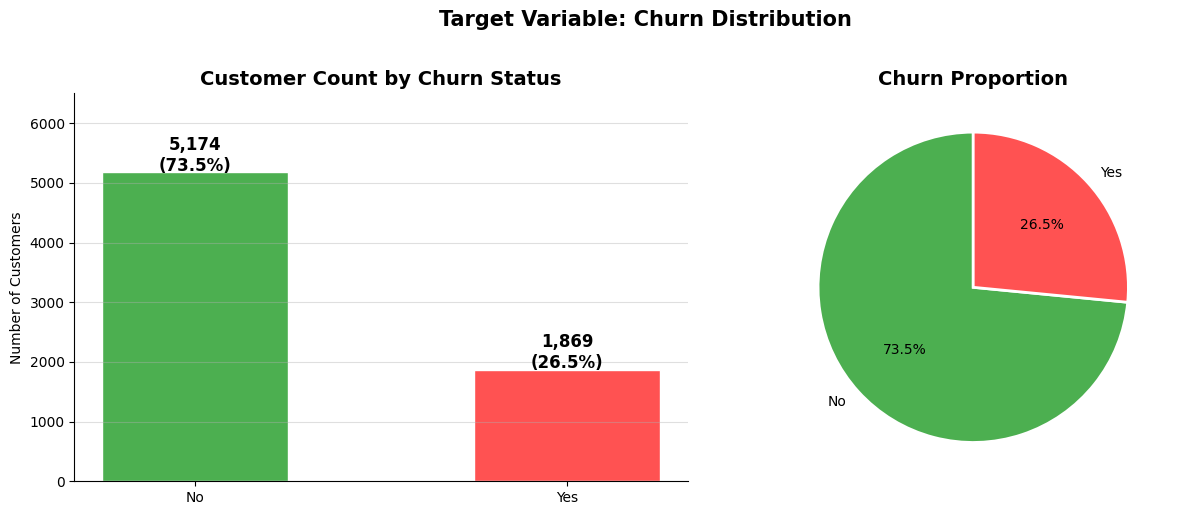


📌 Dataset is imbalanced — only 26.5% churned.
   → Accuracy is misleading here. We track Recall, AUC-PR, and F1 for the Churned class.


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

churn_counts = df['Churn'].value_counts()
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[CHURN_COLORS['No'], CHURN_COLORS['Yes']],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Customer Count by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, 6500)
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].pie(churn_counts.values, labels=churn_counts.index,
            colors=[CHURN_COLORS['No'], CHURN_COLORS['Yes']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Churn Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📌 Dataset is imbalanced — only {df["Churn_Binary"].mean()*100:.1f}% churned.')
print('   → Accuracy is misleading here. We track Recall, AUC-PR, and F1 for the Churned class.')


### 3b. Churn by Contract Type

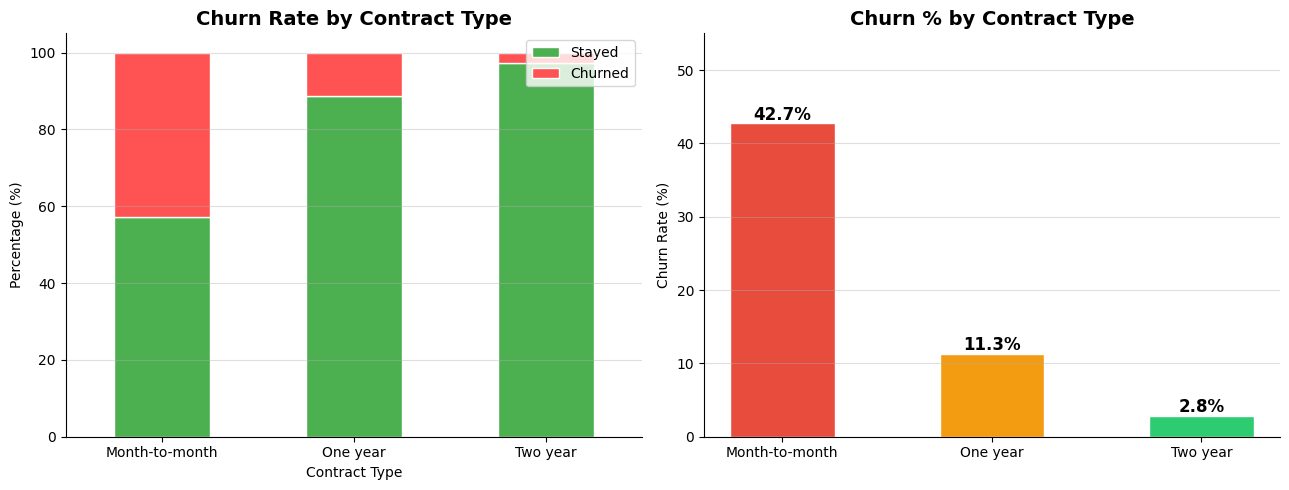

📌 Month-to-month: 42.7% churn rate
📌 One year: 11.3% churn rate
📌 Two year: 2.8% churn rate


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_pivot = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
ct_pivot[['No', 'Yes']].plot(kind='bar', stacked=True,
                              color=[CHURN_COLORS['No'], CHURN_COLORS['Yes']],
                              ax=axes[0], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Contract Type')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Stayed', 'Churned'], loc='upper right')
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

churn_by_contract = df.groupby('Contract')['Churn_Binary'].mean().sort_values(ascending=False) * 100
bars = axes[1].bar(churn_by_contract.index, churn_by_contract.values,
                   color=['#E74C3C', '#F39C12', '#2ECC71'], width=0.5, edgecolor='white')
for bar, val in zip(bars, churn_by_contract.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Churn % by Contract Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

for contract, rate in churn_by_contract.items():
    print(f'📌 {contract}: {rate:.1f}% churn rate')


### 3c. Tenure Distribution

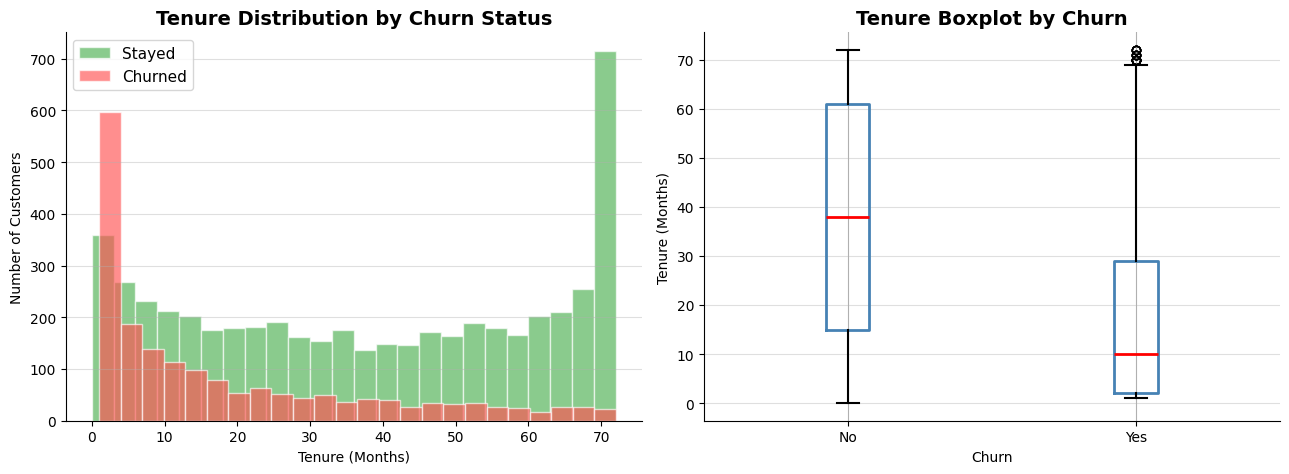

📌 Avg tenure — Churned: 18.0 months
📌 Avg tenure — Stayed: 37.6 months
📌 Short-tenure customers are the highest churn risk — target them early!


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for churn_val, color, label in [(0, CHURN_COLORS['No'], 'Stayed'), (1, CHURN_COLORS['Yes'], 'Churned')]:
    axes[0].hist(df[df['Churn_Binary'] == churn_val]['tenure'],
                 bins=24, alpha=0.65, color=color, label=label, edgecolor='white')
axes[0].set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

df.boxplot(column='tenure', by='Churn', ax=axes[1],
           boxprops=dict(color='steelblue', linewidth=2),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5))
axes[1].set_title('Tenure Boxplot by Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (Months)')
plt.suptitle('')
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('📌 Avg tenure — Churned:', round(df[df['Churn']=='Yes']['tenure'].mean(), 1), 'months')
print('📌 Avg tenure — Stayed:', round(df[df['Churn']=='No']['tenure'].mean(), 1), 'months')
print('📌 Short-tenure customers are the highest churn risk — target them early!')


### 3d. Monthly Charges & Tenure vs Charges

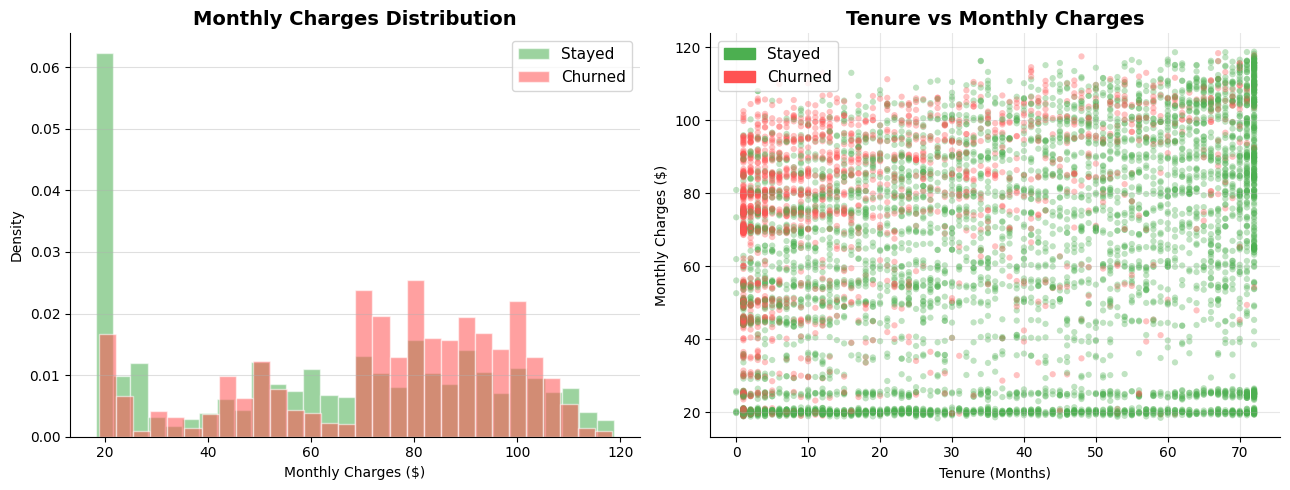

📌 Avg Monthly Charge — Churned: $ 74.44
📌 Avg Monthly Charge — Stayed:  $ 61.27


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for churn_val, color, label in [('No', CHURN_COLORS['No'], 'Stayed'), ('Yes', CHURN_COLORS['Yes'], 'Churned')]:
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    axes[0].hist(subset, bins=30, alpha=0.55, color=color, label=label, edgecolor='white', density=True)
axes[0].set_title('Monthly Charges Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

color_map = df['Churn'].map(CHURN_COLORS)
axes[1].scatter(df['tenure'], df['MonthlyCharges'],
                c=color_map, alpha=0.35, s=20, edgecolors='none')
axes[1].set_title('Tenure vs Monthly Charges', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Monthly Charges ($)')
legend_handles = [mpatches.Patch(color=CHURN_COLORS['No'], label='Stayed'),
                  mpatches.Patch(color=CHURN_COLORS['Yes'], label='Churned')]
axes[1].legend(handles=legend_handles, fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('📌 Avg Monthly Charge — Churned: $', round(df[df['Churn']=='Yes']['MonthlyCharges'].mean(), 2))
print('📌 Avg Monthly Charge — Stayed:  $', round(df[df['Churn']=='No']['MonthlyCharges'].mean(), 2))


### 3e. Correlation Heatmap

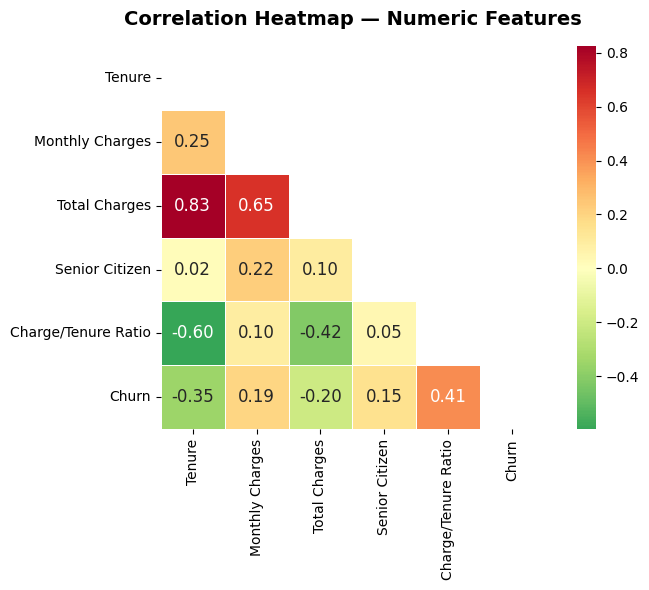

📌 Tenure has NEGATIVE correlation with Churn — longer tenure = less likely to churn
📌 Monthly Charges has POSITIVE correlation with Churn — expensive plans = more churn
📌 Charge/Tenure Ratio: high value = new + expensive customer = highest risk segment


In [42]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges',
                    'SeniorCitizen', 'Charges_Per_Month_Tenure', 'Churn_Binary']].copy()
numeric_df.columns = ['Tenure', 'Monthly Charges', 'Total Charges',
                       'Senior Citizen', 'Charge/Tenure Ratio', 'Churn']

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0,
            linewidths=0.5, square=True, mask=mask,
            annot_kws={'size': 12})
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('📌 Tenure has NEGATIVE correlation with Churn — longer tenure = less likely to churn')
print('📌 Monthly Charges has POSITIVE correlation with Churn — expensive plans = more churn')
print('📌 Charge/Tenure Ratio: high value = new + expensive customer = highest risk segment')


---
## 4. Modelling Pipeline

### 4a. Prepare Features for Modelling


In [43]:
drop_cols = ['Churn', 'Churn_Binary', 'Tenure_Segment', 'Charge_Tier']
df_model = df.drop(columns=drop_cols).copy()

la = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = la.fit_transform(df_model[col].astype(str))

df_model = df_model.astype(float)

X = df_model
y = df['Churn_Binary']

y.value_counts()


,count
Churn_Binary,
0,5174
1,1869


### 4b. Scale, Train/Test Split & SMOTE
> **Why SMOTE?** The dataset is ~73/27 — moderately imbalanced.  
> SMOTE creates *synthetic* minority class samples so the model doesn't default to predicting "No Churn" for everything.  
> We apply SMOTE **only on training data** to prevent data leakage into the test set.


In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print("SMOTE was applied only on training data to improve minority-class learning.")

SMOTE was applied only on training data to improve minority-class learning.


### 4c. Train Models

In [45]:
# ── 1. Logistic Regression
# class_weight='balanced' applies cost-sensitive learning as a complement to SMOTE
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga'],
    'class_weight': ['balanced', None]
}
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_gs = GridSearchCV(lr, lr_params, cv=cv, scoring='recall', n_jobs=-1, verbose=0)
lr_gs.fit(X_train_sm, y_train_sm)

print(f"Logistic Regression")
print(f"   Best params:  {lr_gs.best_params_}")
print(f"   Best CV Recall: {lr_gs.best_score_:.4f}")
best_lr = lr_gs.best_estimator_


Logistic Regression
   Best params:  {'C': 1, 'class_weight': 'balanced', 'solver': 'lbfgs'}
   Best CV Recall: 0.8041


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
# ── 1. XGBoost with scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_gs = GridSearchCV(xgb_model, xgb_params, cv=cv, scoring='recall', n_jobs=-1, verbose=0)
xgb_gs.fit(X_train, y_train)

print(f"\nXGBoost")
print(f"   Best params:  {xgb_gs.best_params_}")
print(f"   Best CV Recall: {xgb_gs.best_score_:.4f}")
best_xgb = xgb_gs.best_estimator_



XGBoost
   Best params:  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
   Best CV Recall: 0.8067


---
## 5. Model Evaluation

### 5a. Summary Table


In [48]:
models = {
    'Logistic Regression': best_lr,
    'XGBoost':             best_xgb
}

results = {}
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    ap      = average_precision_score(y_test, y_proba)
    results[name] = {
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
        'PR-AUC':    round(ap, 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2)
    }

summary_df = pd.DataFrame([{
    'Model':     name,
    'Recall': f"{r['Recall']:.4f}",
    'Precision': f"{r['Precision']:.4f}",
    'F1':        f"{r['F1']:.4f}",
    'PR-AUC':    f"{r['PR-AUC']:.4f}",
    'ROC-AUC':   f"{r['ROC-AUC']:.4f}",
    'Accuracy':  f"{r['Accuracy']}%"
} for name, r in results.items()])

print(summary_df.to_string(index=False))

              Model Recall Precision     F1 PR-AUC ROC-AUC Accuracy
Logistic Regression 0.7807    0.5069 0.6147 0.6602  0.8439   74.02%
            XGBoost 0.8075    0.5093 0.6246 0.6573  0.8452   74.24%


### 5b. Precision-Recall Curves

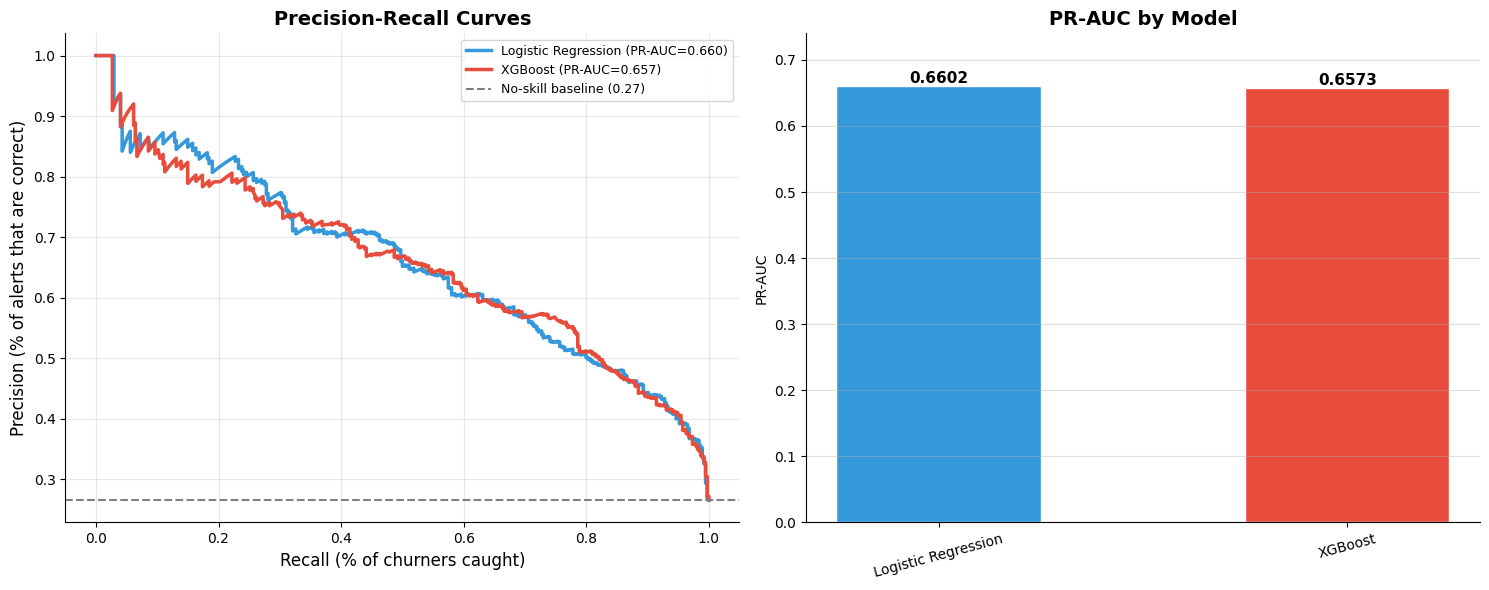

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
model_colors = ['#3498DB', '#E74C3C', '#F39C12', '#9B59B6']

# ── Left: PR curves
for (name, r), color in zip(results.items(), model_colors):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[0].plot(rec, prec, color=color, lw=2.5,
                 label=f"{name} (PR-AUC={r['PR-AUC']:.3f})")

baseline = y_test.mean()
axes[0].axhline(baseline, linestyle='--', color='gray', lw=1.5,
                label=f'No-skill baseline ({baseline:.2f})')
axes[0].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Recall (% of churners caught)', fontsize=12)
axes[0].set_ylabel('Precision (% of alerts that are correct)', fontsize=12)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# ── Right: PR-AUC bar chart
pr_aucs = {name: r['PR-AUC'] for name, r in results.items()}
bars = axes[1].bar(pr_aucs.keys(), pr_aucs.values(),
                   color=model_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, pr_aucs.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('PR-AUC by Model', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PR-AUC')
axes[1].set_ylim(0, max(pr_aucs.values()) + 0.08)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 5e. Confusion Matrices

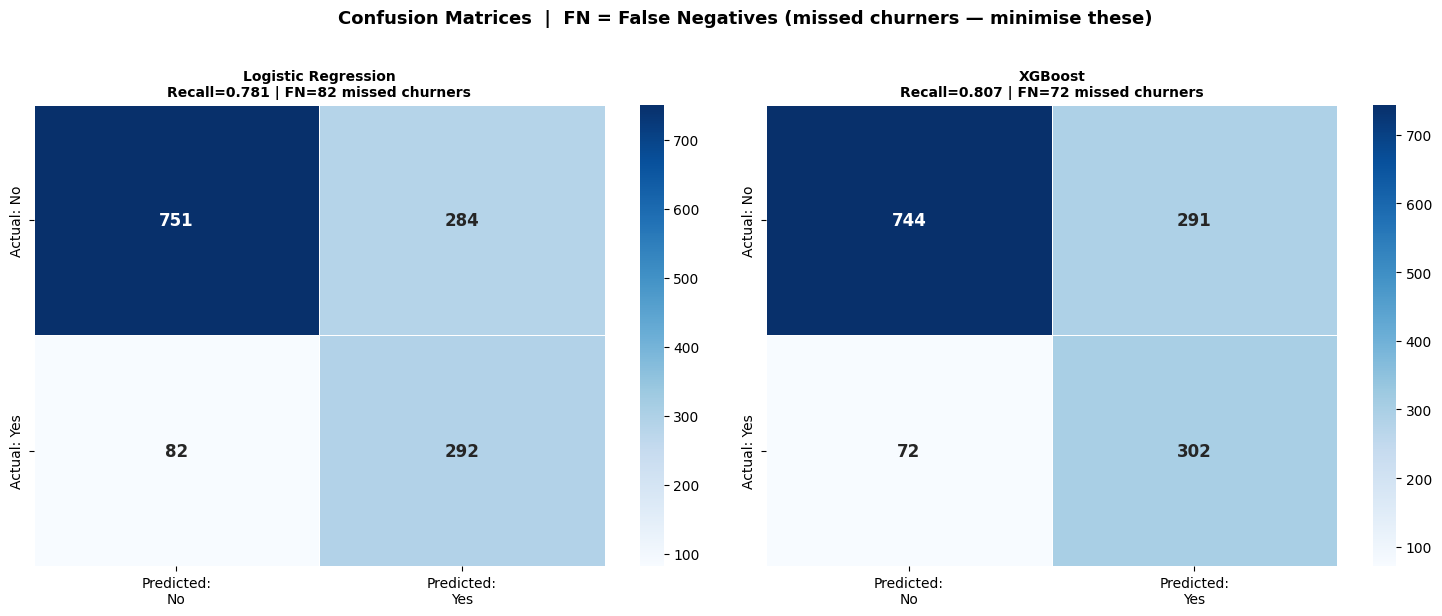

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted:\nNo', 'Predicted:\nYes'],
                yticklabels=['Actual: No', 'Actual: Yes'],
                linewidths=0.5, ax=ax, annot_kws={'size': 12, 'weight': 'bold'})
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{name}\nRecall={r["Recall"]:.3f} | FN={fn} missed churners',
        fontsize=10, fontweight='bold'
    )

plt.suptitle('Confusion Matrices  |  FN = False Negatives (missed churners — minimise these)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Threshold Tuning — Recall vs Precision Trade-off

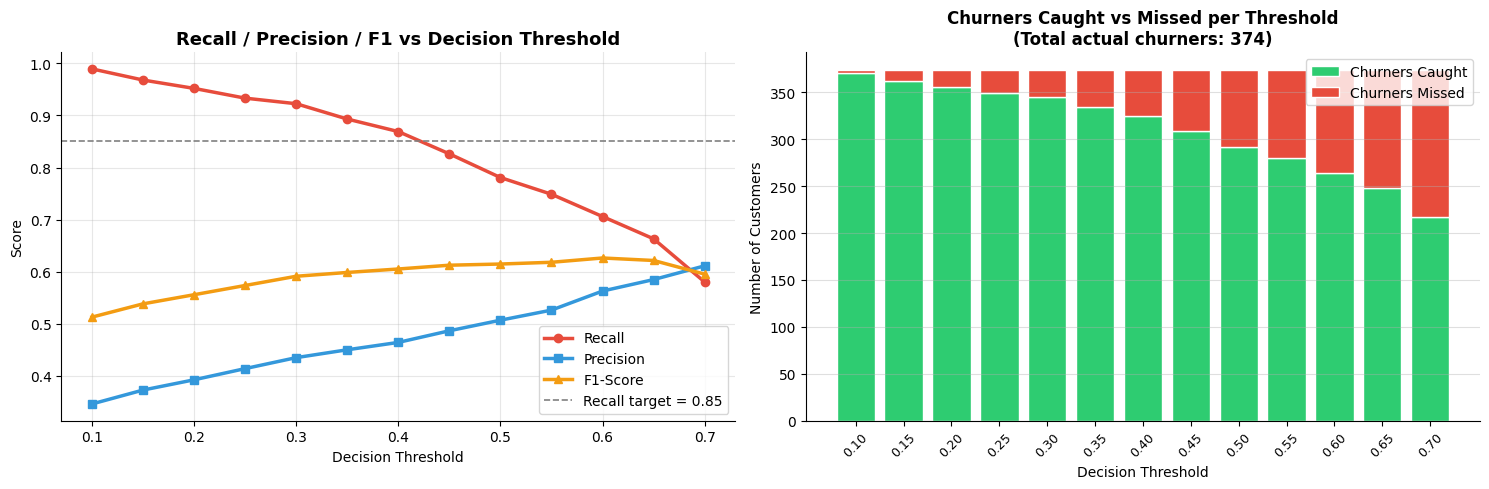


Recommended threshold: 0.40
   Recall:    0.8690  (catches 325/374 churners)
   Precision: 0.4643
   F1-Score:  0.6052


In [51]:
 # Use the best model by PR-AUC for threshold tuning
best_model_name = max(results, key=lambda k: results[k]['PR-AUC'])
best_proba      = results[best_model_name]['y_proba']

thresholds   = np.arange(0.10, 0.71, 0.05)
recall_vals  = []
prec_vals    = []
f1_vals      = []

for thr in thresholds:
    y_pred_thr = (best_proba >= thr).astype(int)
    recall_vals.append(recall_score(y_test, y_pred_thr))
    prec_vals.append(precision_score(y_test, y_pred_thr, zero_division=0))
    f1_vals.append(f1_score(y_test, y_pred_thr, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Recall vs Precision curve across thresholds
axes[0].plot(thresholds, recall_vals,  'o-', color='#E74C3C', lw=2.5, label='Recall')
axes[0].plot(thresholds, prec_vals,    's-', color='#3498DB', lw=2.5, label='Precision')
axes[0].plot(thresholds, f1_vals,      '^-', color='#F39C12', lw=2.5, label='F1-Score')
axes[0].axhline(0.85, linestyle='--', color='gray', lw=1.2, label='Recall target = 0.85')
axes[0].set_title('Recall / Precision / F1 vs Decision Threshold',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# ── Right: number of churners caught vs missed
caught = [recall_score(y_test, (best_proba >= t).astype(int)) * y_test.sum() for t in thresholds]
missed = [y_test.sum() - c for c in caught]
total_pos = int(y_test.sum())

x_pos = np.arange(len(thresholds))
axes[1].bar(x_pos, caught, label='Churners Caught', color='#2ECC71', edgecolor='white')
axes[1].bar(x_pos, missed, bottom=caught, label='Churners Missed', color='#E74C3C', edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'{t:.2f}' for t in thresholds], rotation=45, fontsize=9)
axes[1].set_title(f'Churners Caught vs Missed per Threshold\n(Total actual churners: {total_pos})',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xlabel('Decision Threshold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ── Best threshold: maximise recall while recall >= 0.85
target_recall = 0.85
valid = [(thr, rec, prec, f1)
         for thr, rec, prec, f1 in zip(thresholds, recall_vals, prec_vals, f1_vals)
         if rec >= target_recall]

if valid:
    # Pick the one with highest precision among those meeting recall target
    opt_thr, opt_rec, opt_prec, opt_f1 = max(valid, key=lambda x: x[2])
    print(f"\nRecommended threshold: {opt_thr:.2f}")
    print(f"   Recall:    {opt_rec:.4f}  (catches {int(opt_rec * total_pos)}/{total_pos} churners)")
    print(f"   Precision: {opt_prec:.4f}")
    print(f"   F1-Score:  {opt_f1:.4f}")
else:
    opt_thr = 0.30
    print(f"\n No threshold achieved recall ≥ {target_recall}. Using {opt_thr:.2f} as conservative default.")


### 6a. Apply Optimal Threshold — Final Evaluation

In [52]:
best_model_obj = models[best_model_name]
y_pred_opt = (results[best_model_name]['y_proba'] >= opt_thr).astype(int)

print(f"{'='*55}")
print(f"  {best_model_name} @ threshold = {opt_thr:.2f}")
print('='*55)
print(classification_report(y_test, y_pred_opt, target_names=['Not Churned', 'Churned']))

cm_opt = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm_opt.ravel()
print(f"True Positives  (churners caught):  {tp}")
print(f"False Negatives (churners missed):  {fn}  ← minimise this!")
print(f"False Positives (unnecessary alerts): {fp}")
print(f"True Negatives  (correct non-churn):  {tn}")


  Logistic Regression @ threshold = 0.40
              precision    recall  f1-score   support

 Not Churned       0.93      0.64      0.76      1035
     Churned       0.46      0.87      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409

True Positives  (churners caught):  325
False Negatives (churners missed):  49  ← minimise this!
False Positives (unnecessary alerts): 375
True Negatives  (correct non-churn):  660


---
## 7. Feature Importance

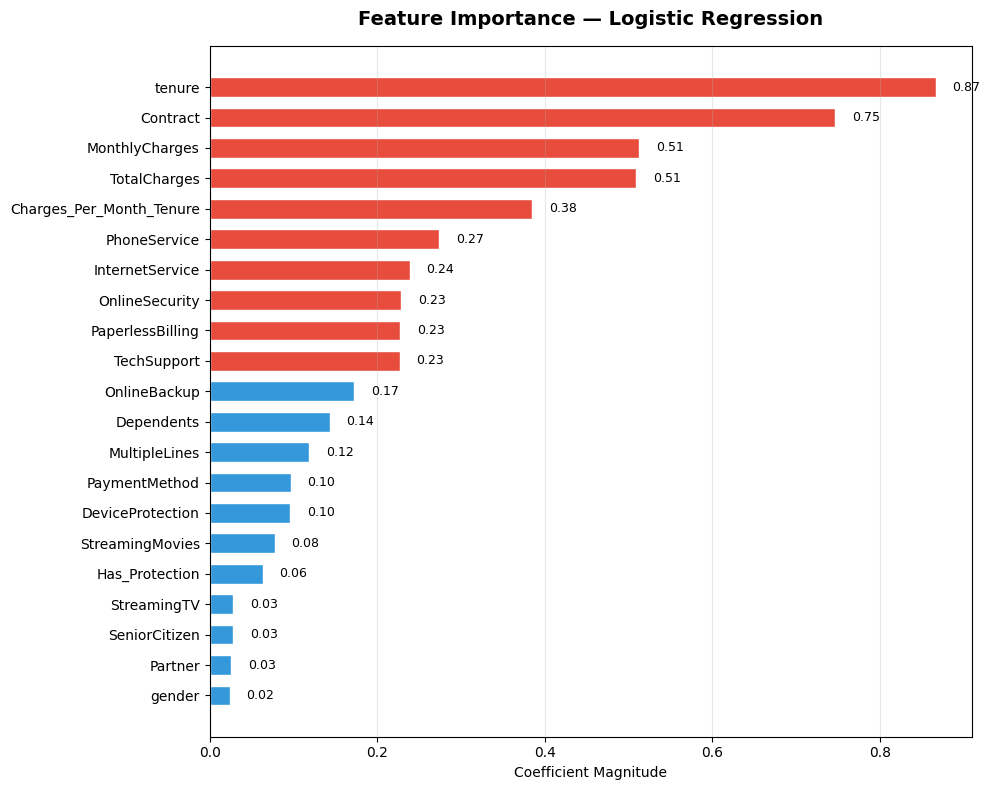


🔑 Top Features Associated with Churn:
   tenure                             : 0.87
   Contract                           : 0.75
   MonthlyCharges                     : 0.51
   TotalCharges                       : 0.51
   Charges_Per_Month_Tenure           : 0.38


In [53]:
# Feature importance using Logistic Regression coefficients

coef_series = pd.Series(
    abs(best_lr.coef_[0]),
    index=df_model.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))

colors_fi = ['#E74C3C' if v > coef_series.median() else '#3498DB'
             for v in coef_series]

plt.barh(
    coef_series.index,
    coef_series.values,
    color=colors_fi,
    edgecolor='white',
    height=0.65
)

plt.title('Feature Importance — Logistic Regression',
          fontsize=14,
          fontweight='bold',
          pad=15)

plt.xlabel('Coefficient Magnitude')
plt.grid(axis='x', alpha=0.3)

for i, val in enumerate(coef_series.values):
    plt.text(val + 0.02, i, f'{val:.2f}',
             va='center',
             fontsize=9)

plt.tight_layout()
plt.show()

top5 = coef_series.sort_values(ascending=False).head(5)

print("\n🔑 Top Features Associated with Churn:")

for feat, imp in top5.items():
    print(f"   {feat:35s}: {imp:.2f}")

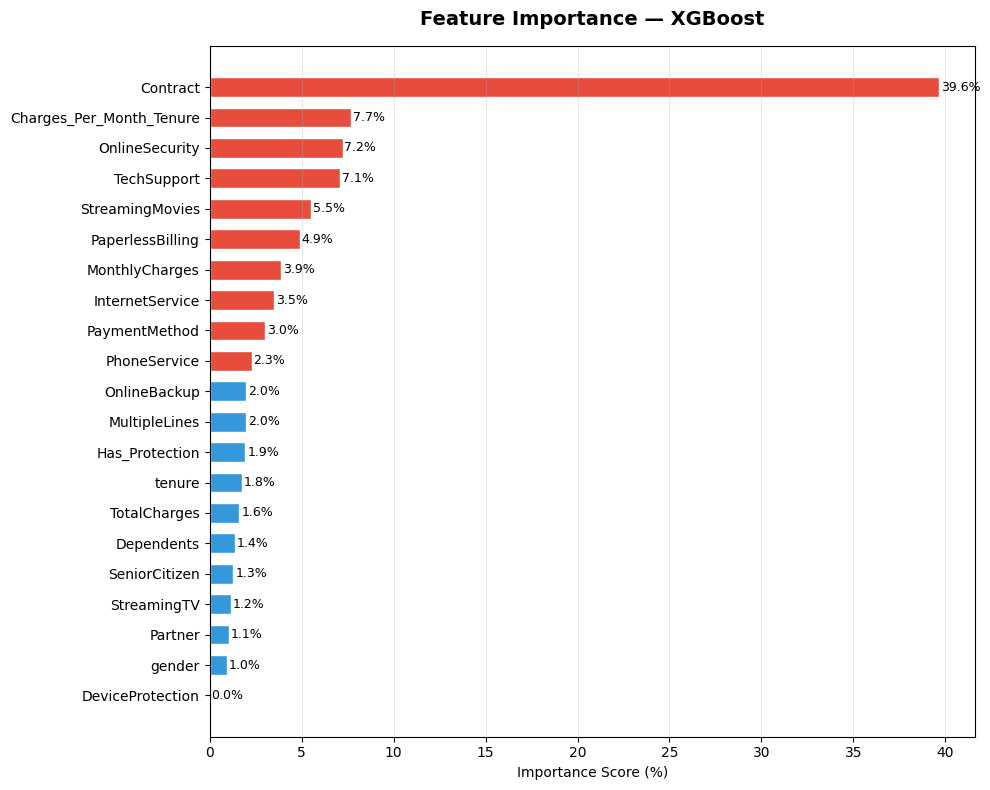


🔑 Top Features Associated with Churn:
   Contract                           : 39.6%
   Charges_Per_Month_Tenure           : 7.7%
   OnlineSecurity                     : 7.2%
   TechSupport                        : 7.1%
   StreamingMovies                    : 5.5%


In [54]:
# Feature Importance — XGBoost

xgb_model = best_xgb

feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=df_model.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))

colors_fi = [
    '#E74C3C' if v > feat_imp.median() else '#3498DB'
    for v in feat_imp
]

plt.barh(
    feat_imp.index,
    feat_imp.values * 100,
    color=colors_fi,
    edgecolor='white',
    height=0.65
)

plt.title(
    'Feature Importance — XGBoost',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Importance Score (%)')
plt.grid(axis='x', alpha=0.3)

for i, val in enumerate(feat_imp.values * 100):
    plt.text(
        val + 0.1,
        i,
        f'{val:.1f}%',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

top5 = feat_imp.sort_values(ascending=False).head(5)

print("\n🔑 Top Features Associated with Churn:")

for feat, imp in top5.items():
    print(f"   {feat:35s}: {imp*100:.1f}%")

---
## 8. Final Model Summary & Business Recommendations

In [55]:
print("=" * 60)
print(" FINAL MODEL COMPARISON")
print("=" * 60)

summary_sorted = pd.DataFrame([{
    'Model':       name,
    'Recall':  r['Recall'],
    'Precision':   r['Precision'],
    'F1':          r['F1'],
    'PR-AUC':      r['PR-AUC'],
    'ROC-AUC':     r['ROC-AUC'],
    'Accuracy':    f"{r['Accuracy']}%"
} for name, r in results.items()]).sort_values('Recall', ascending=False)

print(summary_sorted.to_string(index=False))

best_recall_model = summary_sorted.iloc[0]['Model']
print(f"\nBest model by Recall: {best_recall_model}")
print(f"   With threshold tuning @ {opt_thr:.2f} → Recall = {opt_rec:.4f}")
print(f"   Catches {int(opt_rec * total_pos)} out of {total_pos} churners in the test set")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 BUSINESS RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. DEPLOY with lowered threshold (see Section 6) — catching
   more churners far outweighs the cost of extra retention calls.

2. PRIORITY SEGMENTS to target with retention offers:
   • Month-to-month contract customers (>42% churn rate)
   • High MonthlyCharges + low tenure (new, expensive = high risk)
   • Customers without OnlineSecurity or OnlineBackup

3. MONITOR Recall monthly on fresh data — concept drift
   (e.g. pricing changes) will erode model performance.

4. NEXT STEPS:
   • A/B test retention offer effectiveness on flagged customers
   • Re-train quarterly with updated data
   • Explore customer lifetime value to weight FN cost more precisely
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


 FINAL MODEL COMPARISON
              Model  Recall  Precision     F1  PR-AUC  ROC-AUC Accuracy
            XGBoost  0.8075     0.5093 0.6246  0.6573   0.8452   74.24%
Logistic Regression  0.7807     0.5069 0.6147  0.6602   0.8439   74.02%

Best model by Recall: XGBoost
   With threshold tuning @ 0.40 → Recall = 0.8690
   Catches 325 out of 374 churners in the test set

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 BUSINESS RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. DEPLOY with lowered threshold (see Section 6) — catching
   more churners far outweighs the cost of extra retention calls.

2. PRIORITY SEGMENTS to target with retention offers:
   • Month-to-month contract customers (>42% churn rate)
   • High MonthlyCharges + low tenure (new, expensive = high risk)
   • Customers without OnlineSecurity or OnlineBackup

3. MONITOR Recall monthly on fresh data — concept drift
   (e.g. pricing changes) will erode model performance.

4. NE